In [46]:
import pandas as pd
import os
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.dataframe import NWB_to_dataframe
import matplotlib.pylab as plt

import seaborn as sns
from physion.utils import plot_tools as pt


#stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols


In [2]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]
index = 8
filename = SESSIONS['files'][index]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 13.1s) 


In [3]:
df_ = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframe['dFoF-ROI%i'%i] = Normalize(data.dFoF[i,:])
C:\Users\laura.gonzalez\AppData\Roaming\Python\Python312\site-packages\physion\analysis\dataframe.py:65: PerformanceWarning:

In [13]:
data = Data(filename, verbose=False)
data.build_dFoF()
data.t_dFoF[-1]
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pupil_size_dFoF_sampled = data.build_pupil_diameter(specific_time_sampling=data.t_dFoF)

df = pd.DataFrame()

df['dFoF'] = data.dFoF.mean(axis=0)   #average of all ROIs

df['running_speed'] = running_dFoF_sampled
df['behav_state'] = df['running_speed'].apply(lambda speed: True if speed > 0.1 else False)

#df['pupil_size'] = pupil_size_dFoF_sampled
#df['aroused_state'] = df['pupil_size'].apply(lambda pupil_size: True if pupil_size > 2.9 else False)

df['stim_cond'] = (~df_['VisStim_grey-10min'])

print(df)



calculating dF/F with method "percentile" [...]

  ** 15 ROIs were discarded with the positive F0 criterion (12.5%) ** 

-> dFoF calculus done !  (calculation took 0.1s)
           dFoF  running_speed  behav_state  stim_cond
0      2.031212       0.000000        False       True
1      2.109512       0.000000        False       True
2      1.762196       0.000000        False       True
3      1.472235       0.000000        False       True
4      1.575318       0.000000        False       True
...         ...            ...          ...        ...
59554  0.919641       0.169372         True       True
59555  1.065641       0.169372         True       True
59556  1.080562       0.169372         True       True
59557  0.971785       0.169372         True       True
59558  1.102477       0.169372         True       True

[59559 rows x 4 columns]


<Figure size 1200x300 with 0 Axes>

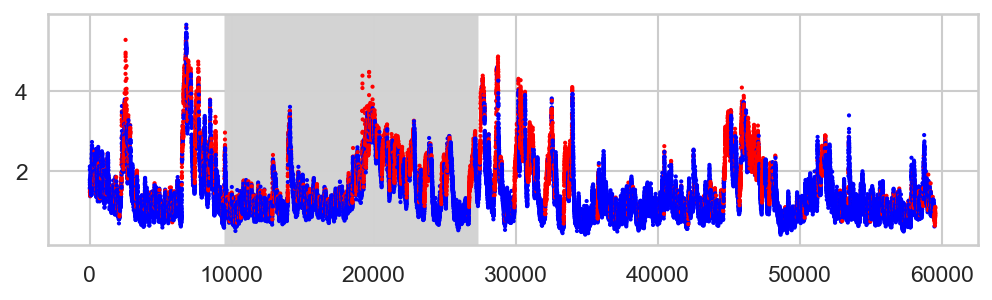

In [90]:
plt.figure(figsize=(8, 2))

fig, ax = pt.plt.subplots(1, 1, figsize=(8,2))

for i in range(len(df) - 1):
    if df['stim_cond'].iloc[i] == False:
        ax.axvspan(i, i+1, color='lightgrey', alpha=0.5)
        
ax.scatter(x = df['dFoF'].index, 
           y = df['dFoF'],  
           color = ['blue' if state == False else 'orangered' for state in df['behav_state']],
           s=1)

False False
False True
True False
True True


<Figure size 750x300 with 0 Axes>

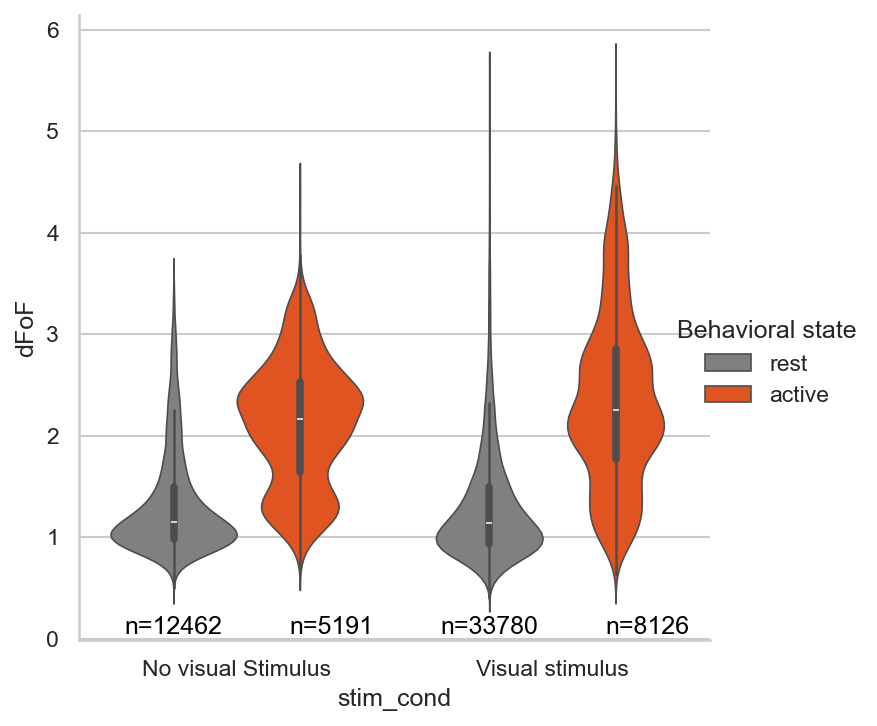

In [133]:
# Set plot style
sns.set(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(5, 2))
g = sns.catplot(data=df, 
                 kind = 'violin',
                 x='stim_cond', 
                 y='dFoF', 
                 hue='behav_state', 
                 palette=['grey', 'orangered'], 
                 linewidth=0.8, 
                 legend_out = True)

g.set_xticklabels(["No visual Stimulus", "Visual stimulus"])
new_title = 'Behavioral state'
g._legend.set_title(new_title)
new_labels = ['rest', 'active']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    

ax = g.ax  # Get the matplotlib axis
grouped = df.groupby(["stim_cond", "behav_state"]).size().reset_index(name='count')
for i, (x, hue) in enumerate(zip(grouped["stim_cond"], grouped["behav_state"])):
    print(x, hue)
    n = grouped.loc[(grouped["stim_cond"] == x) & (grouped["behav_state"] == hue), "count"].values[0]
    ax.text(i/2-0.2, 0, f"n={n}", ha="center", va="bottom", fontsize=12, color="black")




plt.show()

Statistics: Linear Mixed effect model

In [142]:
md = smf.mixedlm("dFoF ~ behav_state", df, groups=df['stim_cond'])
mdf = md.fit()
print(mdf.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  dFoF       
No. Observations:    59559    Method:              REML       
No. Groups:          2        Scale:               0.3627     
Min. group size:     17653    Log-Likelihood:      -54323.0632
Max. group size:     41906    Converged:           Yes        
Mean group size:     29779.5                                  
--------------------------------------------------------------
                    Coef. Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           1.298    0.019  66.627 0.000  1.259  1.336
behav_state[T.True] 0.962    0.006 161.413 0.000  0.950  0.974
Group Var           0.001    0.002                            



C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\laura.gonzalez\AppData\Local\miniforge3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 2 Way-ANOVA

Assumptions
1) Homogeneity of variance (a.k.a. homoscedasticity)
The variation around the mean for each group being compared should be similar among all groups. If your data don’t meet this assumption, you may be able to use a non-parametric alternative, like the Kruskal-Wallis test.

2) Independence of observations
Your independent variables should not be dependent on one another (i.e. one should not cause the other). This is impossible to test with categorical variables – it can only be ensured by good experimental design. <br>
In addition, your dependent variable should represent unique observations – that is, your observations should not be grouped within locations or individuals.<br>
If your data don’t meet this assumption (i.e. if you set up experimental treatments within blocks), you can include a blocking variable and/or use a repeated-measures ANOVA.<br>

3) Normally-distributed dependent variable
The values of the dependent variable should follow a bell curve (they should be normally distributed). If your data don’t meet this assumption, you can try a data transformation.


In [141]:
# Performing two-way ANOVA 
md = ols('dFoF ~ C(stim_cond) + C(behav_state) + C(stim_cond):C(behav_state)', data=df)
mdf = md.fit()
result = sm.stats.anova_lm(mdf, type=2)  
print(result) 

                                  df        sum_sq      mean_sq             F  \
C(stim_cond)                     1.0     41.028117    41.028117    113.969296   
C(behav_state)                   1.0   9455.124074  9455.124074  26264.764682   
C(stim_cond):C(behav_state)      1.0    164.489856   164.489856    456.925507   
Residual                     59555.0  21439.366430     0.359993           NaN   

                                    PR(>F)  
C(stim_cond)                  1.398817e-26  
C(behav_state)                0.000000e+00  
C(stim_cond):C(behav_state)  5.386488e-101  
Residual                               NaN  


dFoF significantly affected by the behavioral state, stimulus condition, and the interaction between the 2?